# Story Visuals - beautiful figures for the narrative

**Author:** kj · **Purpose:** presentation-grade images that complement the README story

This notebook is a *design* artefact, not an analysis one. It reuses the validated coupled behavioural x
Leslie model (E19/E22) for the underlying numbers and spends its effort on the rendering - a restrained
"warm paper" aesthetic, a two-colour palette (teal for recovery, rose for decline), direct end-labelling
instead of legends, and no chartjunk. Four figures, each matched to a beat of the README:

1. **Two futures, and a very narrow ridge** - one country under a fan of pushes, split by the ridge
2. **What collapse looks like** - the fertility decline across six countries
3. **The one lever that bends** - marriageable-men bending Korea, Germany and the US alike
4. **The cheapest fixes** - the value ranking of the harbingers

## Output

- `reports/figures/story_two_futures.png`, `story_collapse.png`, `story_one_lever.png`, `story_cheapest_fixes.png`


## GPU + Imports

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from rich import print as rprint
from sci_demographic_collapse import coremodel as cm
torch.set_default_dtype(torch.float64)

2026-07-08 19:28:45.303 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## The Design System

A warm-paper light theme with a two-colour story palette. Recovery reads teal, decline reads rose, structure
reads muted graphite. Only the left/bottom spines survive, labels sit at the end of each line, and the type
carries a title/subtitle hierarchy.

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True)
PAPER="#faf8f4"; INK="#242b33"; MUTED="#9aa2ad"; GRID="#e7e2d8"
HOPE="#0e9488"; HOPE_D="#0b7a70"; FALL="#e11d48"; FALL_D="#9f1239"; GOLD="#c2740b"
COOLWARM=LinearSegmentedColormap.from_list("hopefall",[FALL_D,FALL,"#e8b04b",HOPE,HOPE_D])
mpl.rcParams.update({
 "figure.dpi":150,"savefig.dpi":210,"savefig.bbox":"tight","savefig.facecolor":PAPER,
 "figure.facecolor":PAPER,"axes.facecolor":PAPER,"font.family":"DejaVu Sans","font.size":11,
 "axes.edgecolor":MUTED,"axes.linewidth":0.9,"axes.spines.top":False,"axes.spines.right":False,
 "axes.titlesize":15,"axes.titleweight":"bold","axes.labelcolor":INK,"axes.labelsize":11,
 "xtick.color":MUTED,"ytick.color":MUTED,"text.color":INK,"axes.grid":False})
def titled(ax,title,sub):
    ax.set_title(title,color=INK,pad=38,loc="left",fontsize=16)
    ax.text(0,1.015,sub,transform=ax.transAxes,fontsize=10.5,color=MUTED,ha="left",va="bottom")
def caption(fig,txt):
    fig.text(0.007,-0.02,txt,fontsize=8.2,color=MUTED,style="italic",ha="left")
def endlabel(ax,x,y,txt,color,dx=3,fs=10,weight="bold"):
    ax.annotate(txt,(x,y),xytext=(dx,0),textcoords="offset points",va="center",ha="left",
                fontsize=fs,color=color,fontweight=weight)
rprint("[green]design system loaded[/green]")

design system loaded

## The Coupled Model (reused from E19/E22) and Baselines

In [3]:
REG=cm.load_unwpp(data_dir=str(PROJ/"data"/"raw"/"unwpp"),y0=1990,y1=2023); DEV=cm.DEV; RC=cm.rogers_castro()
REAL={"USA":(1.62,29.4),"France":(1.64,31.1),"Germany":(1.44,31.0),"Italy":(1.20,31.8),"Japan":(1.21,31.4),"Korea":(0.72,32.9),"Poland":(1.16,28.5)}
C0={"USA":.90,"France":.95,"Germany":.86,"Italy":.83,"Japan":.80,"Korea":.52,"Poland":.84}
RV0={"USA":.07,"France":.07,"Germany":.09,"Italy":.10,"Japan":.10,"Korea":.08,"Poland":.10}
S0={"USA":.58,"France":.62,"Germany":.52,"Italy":.45,"Japan":.45,"Korea":.40,"Poland":.46}
def fec(t): return np.exp(-0.03*max(t-30,0))
def quantum(C,rv,Pb): return C*(1-rv)*Pb
PB0={nm:T/(C0[nm]*(1-RV0[nm])*fec(m)) for nm,(T,m) in REAL.items()}
P=dict(kC=.08,C_thr=.66,C_floor=.24,decl=.05,gS_C=.9,secC=.0007,kPb=.05,gPb=1.2,secPb=.0010,kTau=.06,gTau=6.0,secTau=.006,kRV=.03,gRV=.012,kS=.06,secS=.0010,kBF=.6,dep_fb=.22)
def estep(nm,st,f,tn,dp,p=P,dt=.25):
    C,rv,Pb,tau,S=st; fS,fC,fPb,fTau,fRV=f
    dS=p["kS"]*(S0[nm]+fS-dp-S)-p["secS"]; Ceq=C0[nm]+p["gS_C"]*(S-S0[nm])+fC-p["secC"]*100*tn
    dC=p["kC"]*(Ceq-C)-p["decl"]*max(p["C_thr"]-C,0)*max(C-p["C_floor"],0)/(p["C_thr"]-p["C_floor"])
    dPb=p["kPb"]*(PB0[nm]+p["gPb"]*fPb-p["secPb"]*100*tn-Pb); dtau=p["kTau"]*(REAL[nm][1]+p["gTau"]*(S0[nm]-S)+fTau+p["secTau"]*100*tn-tau)
    drv=p["kRV"]*(RV0[nm]+p["gRV"]*max(tau-30,0)-0.05*(S-S0[nm])+fRV-rv)
    return np.array([np.clip(C+dt*dC,.02,.999),np.clip(rv+dt*drv,0,.6),max(Pb+dt*dPb,1),np.clip(tau+dt*dtau,24,40),np.clip(S+dt*dS,.05,.95)]),dtau
def shiftp(a,m,dt):
    b=a*m; s=int(round(dt))
    if s>0: b=np.concatenate([np.zeros(min(s,len(b))),b[:-s]]) if s<len(b) else b*0
    elif s<0: b=np.concatenate([b[-s:],np.zeros(min(-s,len(b)))]) if -s<len(b) else b*0
    return np.clip(b,0,None)
def run(nm,fy,years=102):
    st=np.array([C0[nm],RV0[nm],PB0[nm],REAL[nm][1],S0[nm]]); R=REG[nm]
    nf=torch.tensor(R["pop_f"][-1].copy(),device=DEV); nm2=torch.tensor(R["pop_m"][-1].copy(),device=DEV)
    Sx0=R["Sx"][-1].copy(); srb=float(R["ind"]["SRB"][-1]); base=R["asfr"][-1].copy(); tb=base.sum()
    d0=(nf+nm2).cpu().numpy(); dep0=float(d0[65:].sum()/max(d0[20:65].sum(),1)); dp=0; T=[]
    for yr in range(years):
        f=fy(yr); dtau=0
        for _ in range(4): st,dd=estep(nm,st,f,yr/100,dp); dtau+=dd
        C,rv,Pb,tau,S=st; tfr=quantum(C,rv,Pb)*fec(tau)*(1-P["kBF"]*dtau)
        Sx=1-(1-Sx0)*(1-.003)**(yr+1)
        nf,nm2,b,d=cm.leslie_step(nf,nm2,torch.tensor(Sx,device=DEV),torch.tensor(shiftp(base,tfr/tb if tb>1e-6 else 0,tau-REAL[nm][1]),device=DEV),srb,torch.tensor(0*RC,device=DEV))
        T.append(tfr)
    return np.array(T)
def ramp(yr,s=2,d=10): return min(max((yr-s)/d,0),1)
def coupling(mag):  # a coupling push (security + coupling), the shape of the levers that bend fate
    return lambda yr:[1.2*mag*ramp(yr),0.35*mag*ramp(yr),0.,0.,0.]
yrs=np.arange(2023,2125); yrs100=np.arange(2023,2101)
BASE={nm:run(nm,lambda yr:[0]*5) for nm in REAL}
rprint("[green]model ready, baselines computed[/green]")

model ready, baselines computed

## Figure 1 - Two futures, and a very narrow ridge

One country (the United States, which starts near the ridge) under a fan of ever-stronger pushes. Below a
critical effort the lines slide into decline; above it they climb into recovery. The ridge is the hair's
breadth between the two fates.

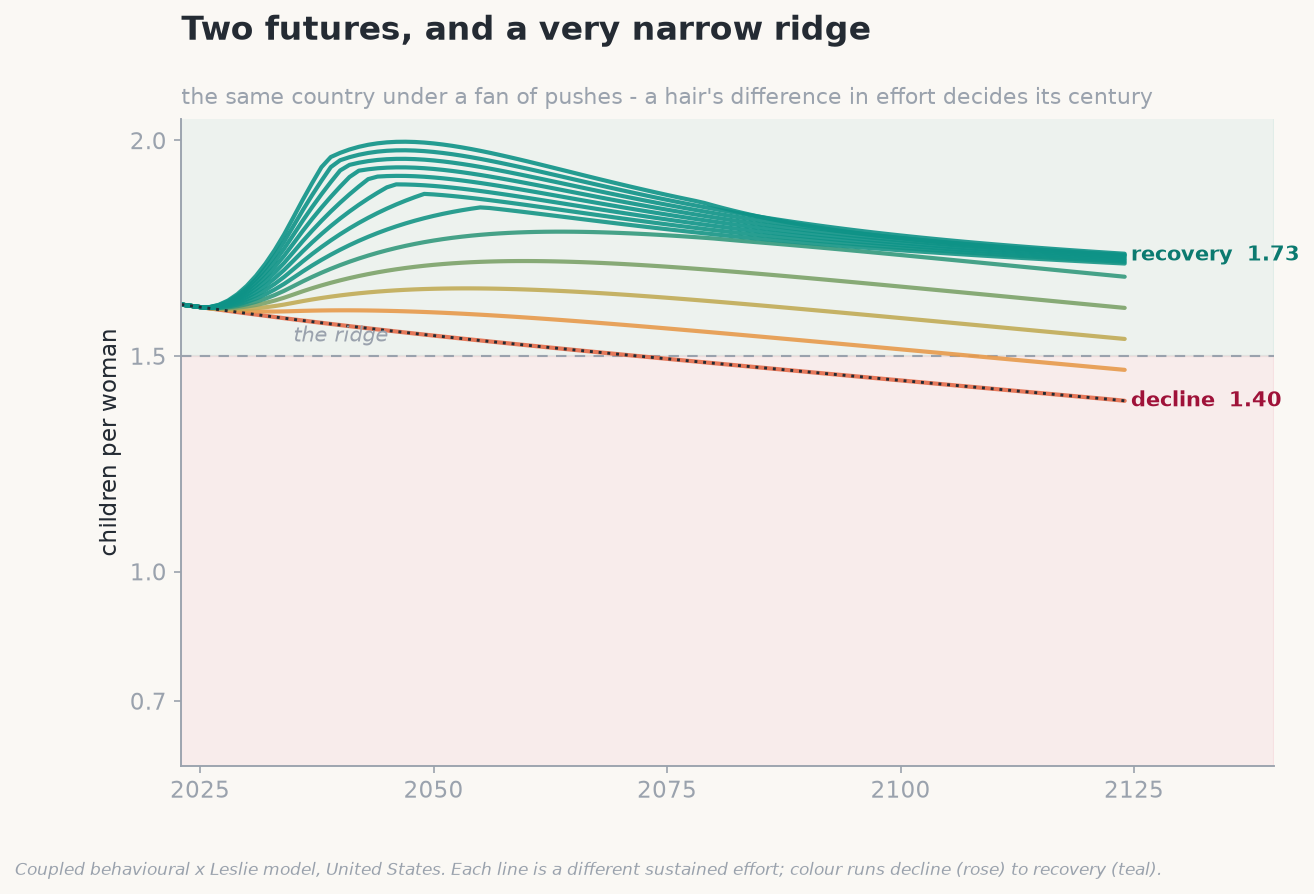

In [4]:
RIDGE=1.5
mags=np.linspace(0,0.34,13)
fig,ax=plt.subplots(figsize=(9.4,5.6))
ax.axhspan(RIDGE,2.2,color=HOPE,alpha=0.05); ax.axhspan(0.3,RIDGE,color=FALL,alpha=0.05)
ax.axhline(RIDGE,color=MUTED,lw=1.0,ls=(0,(5,4)))
finals=[run("USA",coupling(m))[-1] for m in mags]
vmin,vmax=min(finals),max(finals)
for m,fin in zip(mags,finals):
    t=run("USA",coupling(m)); c=COOLWARM((fin-RIDGE)/0.9+0.5)
    ax.plot(yrs,t,color=c,lw=2.0,alpha=0.9,solid_capstyle="round")
ax.plot(yrs,BASE["USA"],color=INK,lw=1.4,ls=(0,(1,2)))
endlabel(ax,yrs[-1],finals[-1],f"recovery  {finals[-1]:.2f}",HOPE_D)
endlabel(ax,yrs[-1],finals[0],f"decline  {finals[0]:.2f}",FALL_D)
ax.annotate("the ridge",(2035,RIDGE),xytext=(0,7),textcoords="offset points",fontsize=10,color=MUTED,fontstyle="italic")
ax.set_xlim(2023,2140); ax.set_ylim(0.55,2.05); ax.set_ylabel("children per woman")
ax.set_yticks([0.7,1.0,1.5,2.0]); ax.set_xticks([2025,2050,2075,2100,2125])
titled(ax,"Two futures, and a very narrow ridge",
       "the same country under a fan of pushes - a hair's difference in effort decides its century")
caption(fig,"Coupled behavioural x Leslie model, United States. Each line is a different sustained effort; colour runs decline (rose) to recovery (teal).")
plt.savefig(FIGS/"story_two_futures.png"); plt.show()

## Figure 2 - What collapse looks like

The fertility decline to 2100 across seven countries, each line labelled at its end. Korea falls off a cliff;
the others - Poland and the West included - sink toward it at different speeds. The faint upper line is
replacement, the level a population needs just to hold steady.

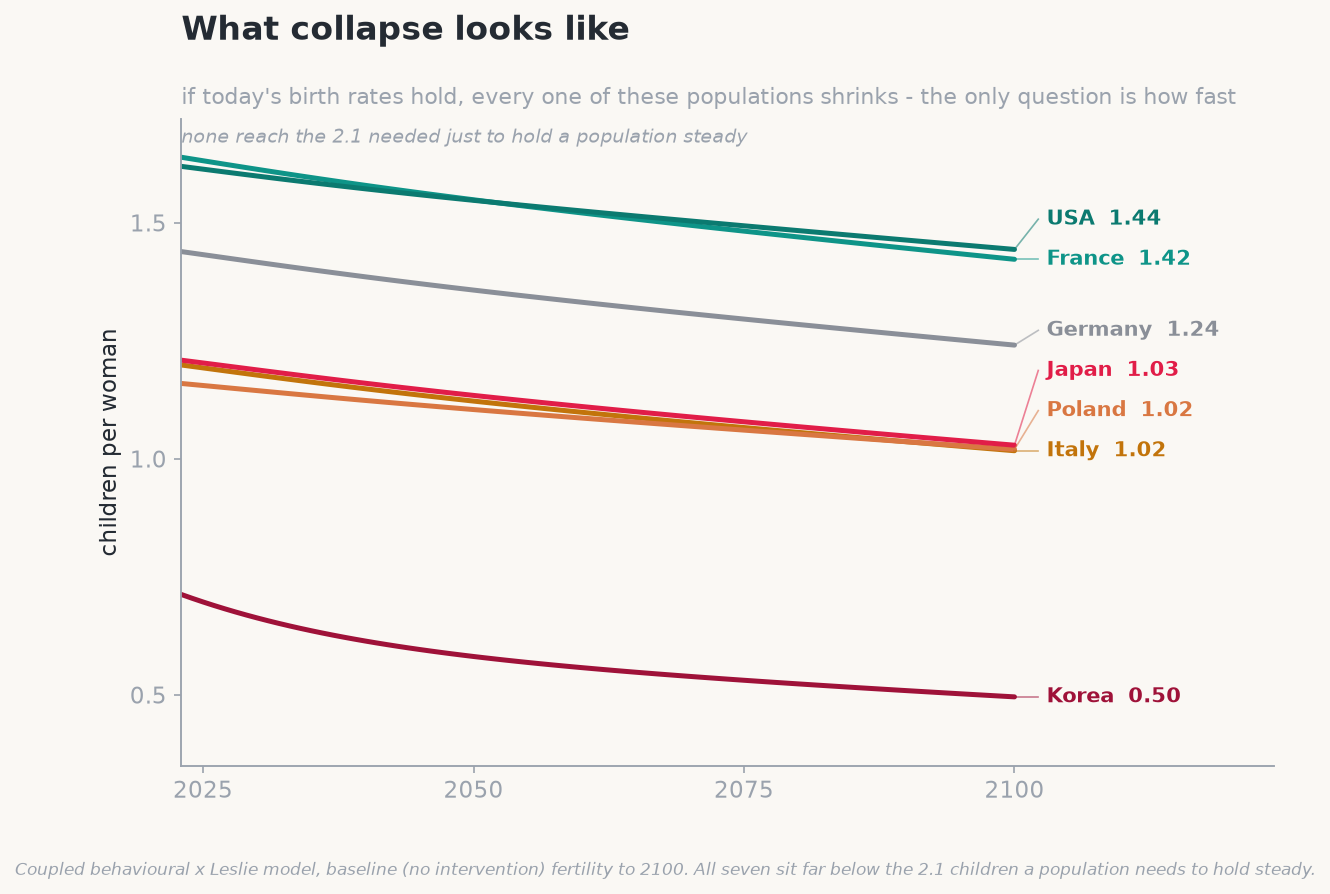

In [5]:
order=sorted(REAL,key=lambda n:BASE[n][78-1])
fig,ax=plt.subplots(figsize=(9.4,5.6))
ax.text(2023,1.70,"none reach the 2.1 needed just to hold a population steady",fontsize=9,color=MUTED,fontstyle="italic",va="top")
pal={"Korea":FALL_D,"Japan":FALL,"Italy":GOLD,"Poland":"#d97742","Germany":"#8a8f98","France":HOPE,"USA":HOPE_D}
items=[]
for nm in order:
    t=BASE[nm][:78]; ax.plot(yrs100,t,color=pal[nm],lw=2.4,solid_capstyle="round")
    items.append((t[-1],f"{nm}  {t[-1]:.2f}",pal[nm]))
items=sorted(items,key=lambda z:z[0]); ys=[z[0] for z in items]; gap=0.085
for i in range(1,len(ys)):
    if ys[i]-ys[i-1]<gap: ys[i]=ys[i-1]+gap
xe=yrs100[-1]
for (y0,txt,c),ya in zip(items,ys):
    ax.plot([xe,xe+2.2],[y0,ya],color=c,lw=0.8,alpha=0.55,clip_on=False)
    ax.annotate(txt,(xe+2.2,ya),xytext=(4,0),textcoords="offset points",va="center",ha="left",fontsize=10,color=c,fontweight="bold")
ax.set_xlim(2023,2124); ax.set_ylim(0.35,1.72); ax.set_ylabel("children per woman")
ax.set_yticks([0.5,1.0,1.5]); ax.set_xticks([2025,2050,2075,2100])
titled(ax,"What collapse looks like","if today's birth rates hold, every one of these populations shrinks - the only question is how fast")
caption(fig,"Coupled behavioural x Leslie model, baseline (no intervention) fertility to 2100. All seven sit far below the 2.1 children a population needs to hold steady.")
plt.savefig(FIGS/"story_collapse.png"); plt.show()

## Figure 3 - The one lever that bends - East and West alike

The single strongest structural lever - restoring the economic prospects of marriageable men - bends the
baseline upward everywhere it is pulled, not only in Korea. Three cases side by side: Korea in the deepest
basin, Germany mid-decline, and the United States near the ridge. The same lever, three different depths of
problem - it turns a collapse into something survivable in the East, and lifts the West back toward the line.

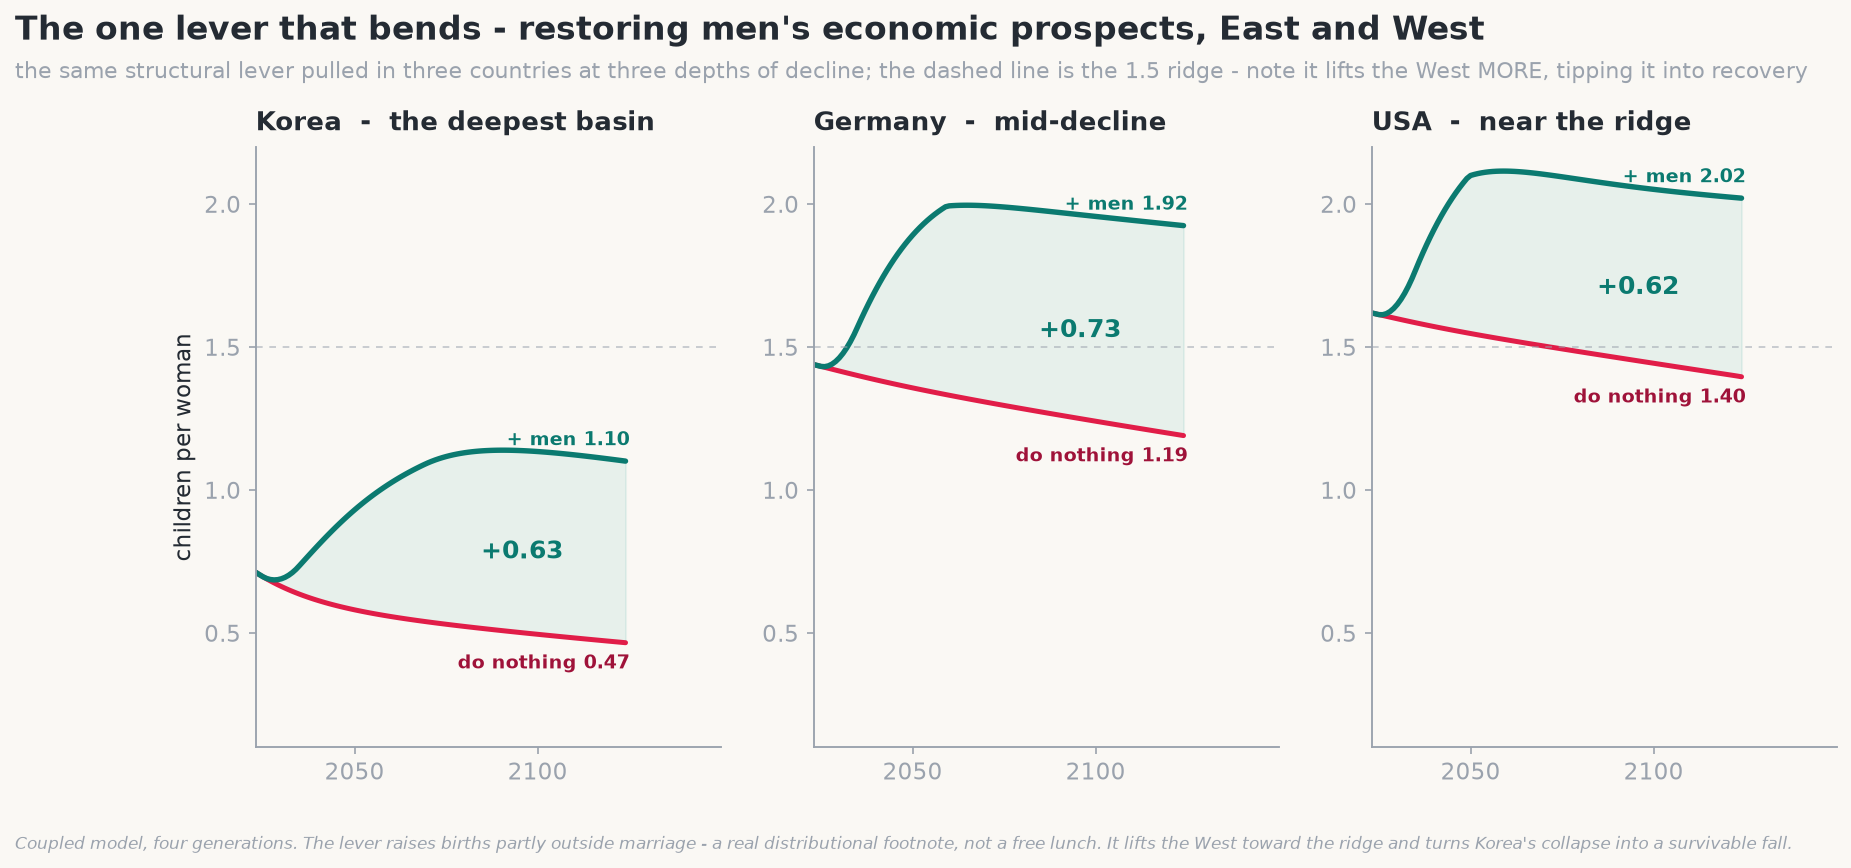

In [6]:
VOC=lambda yr:[1.2*0.20*ramp(yr),0.2*0.20*ramp(yr),1.35*0.20*ramp(yr),0.,0.]
panels=[("Korea","the deepest basin"),("Germany","mid-decline"),("USA","near the ridge")]
fig,axes=plt.subplots(1,3,figsize=(13.6,5.2),sharex=True)
for ax,(nm,sub) in zip(axes,panels):
    b=BASE[nm]; lev=run(nm,VOC)
    ax.fill_between(yrs,b,lev,color=HOPE,alpha=0.08)
    ax.plot(yrs,b,color=FALL,lw=2.4,solid_capstyle="round")
    ax.plot(yrs,lev,color=HOPE_D,lw=2.6,solid_capstyle="round")
    ax.annotate(f"do nothing {b[-1]:.2f}",(yrs[-1],b[-1]),xytext=(2,-10),textcoords="offset points",va="center",ha="right",fontsize=9,color=FALL_D,fontweight="bold")
    ax.annotate(f"+ men {lev[-1]:.2f}",(yrs[-1],lev[-1]),xytext=(2,10),textcoords="offset points",va="center",ha="right",fontsize=9,color=HOPE_D,fontweight="bold")
    ax.annotate(f"+{lev[-1]-b[-1]:.2f}",(yrs[-1],(b[-1]+lev[-1])/2),xytext=(-30,0),textcoords="offset points",fontsize=12,color=HOPE_D,fontweight="bold",va="center",ha="right")
    ax.set_xlim(2023,2150); ax.set_ylim(0.1,2.2); ax.set_xticks([2050,2100]); ax.set_yticks([0.5,1.0,1.5,2.0])
    ax.set_title(f"{nm}  -  {sub}",color=INK,fontsize=12.5,loc="left",pad=8)
    ax.axhline(1.5,color=MUTED,lw=0.8,ls=(0,(4,4)),alpha=0.6)
axes[0].set_ylabel("children per woman")
fig.suptitle("The one lever that bends - restoring men's economic prospects, East and West",
             color=INK,fontsize=16,fontweight="bold",x=0.007,ha="left",y=1.05)
fig.text(0.007,0.99,"the same structural lever pulled in three countries at three depths of decline; the dashed line is the 1.5 ridge - note it lifts the West MORE, tipping it into recovery",
         fontsize=10.5,color=MUTED,ha="left",va="top")
caption(fig,"Coupled model, four generations. The lever raises births partly outside marriage - a real distributional footnote, not a free lunch. It lifts the West toward the ridge and turns Korea's collapse into a survivable fall.")
plt.savefig(FIGS/"story_one_lever.png"); plt.show()

## Figure 4 - What each fix buys, country by country

Every E20 lever re-run through the current calibrated core, shown as its lift in the birth rate (ΔTFR, children per woman) in each of the seven nations - a composite, not one country. Nations are ordered by how low their birth rate has fallen; rows by average effect.

lever x nation grid computed via run_cal  Korea inequality +0.70  male-prospects +0.27

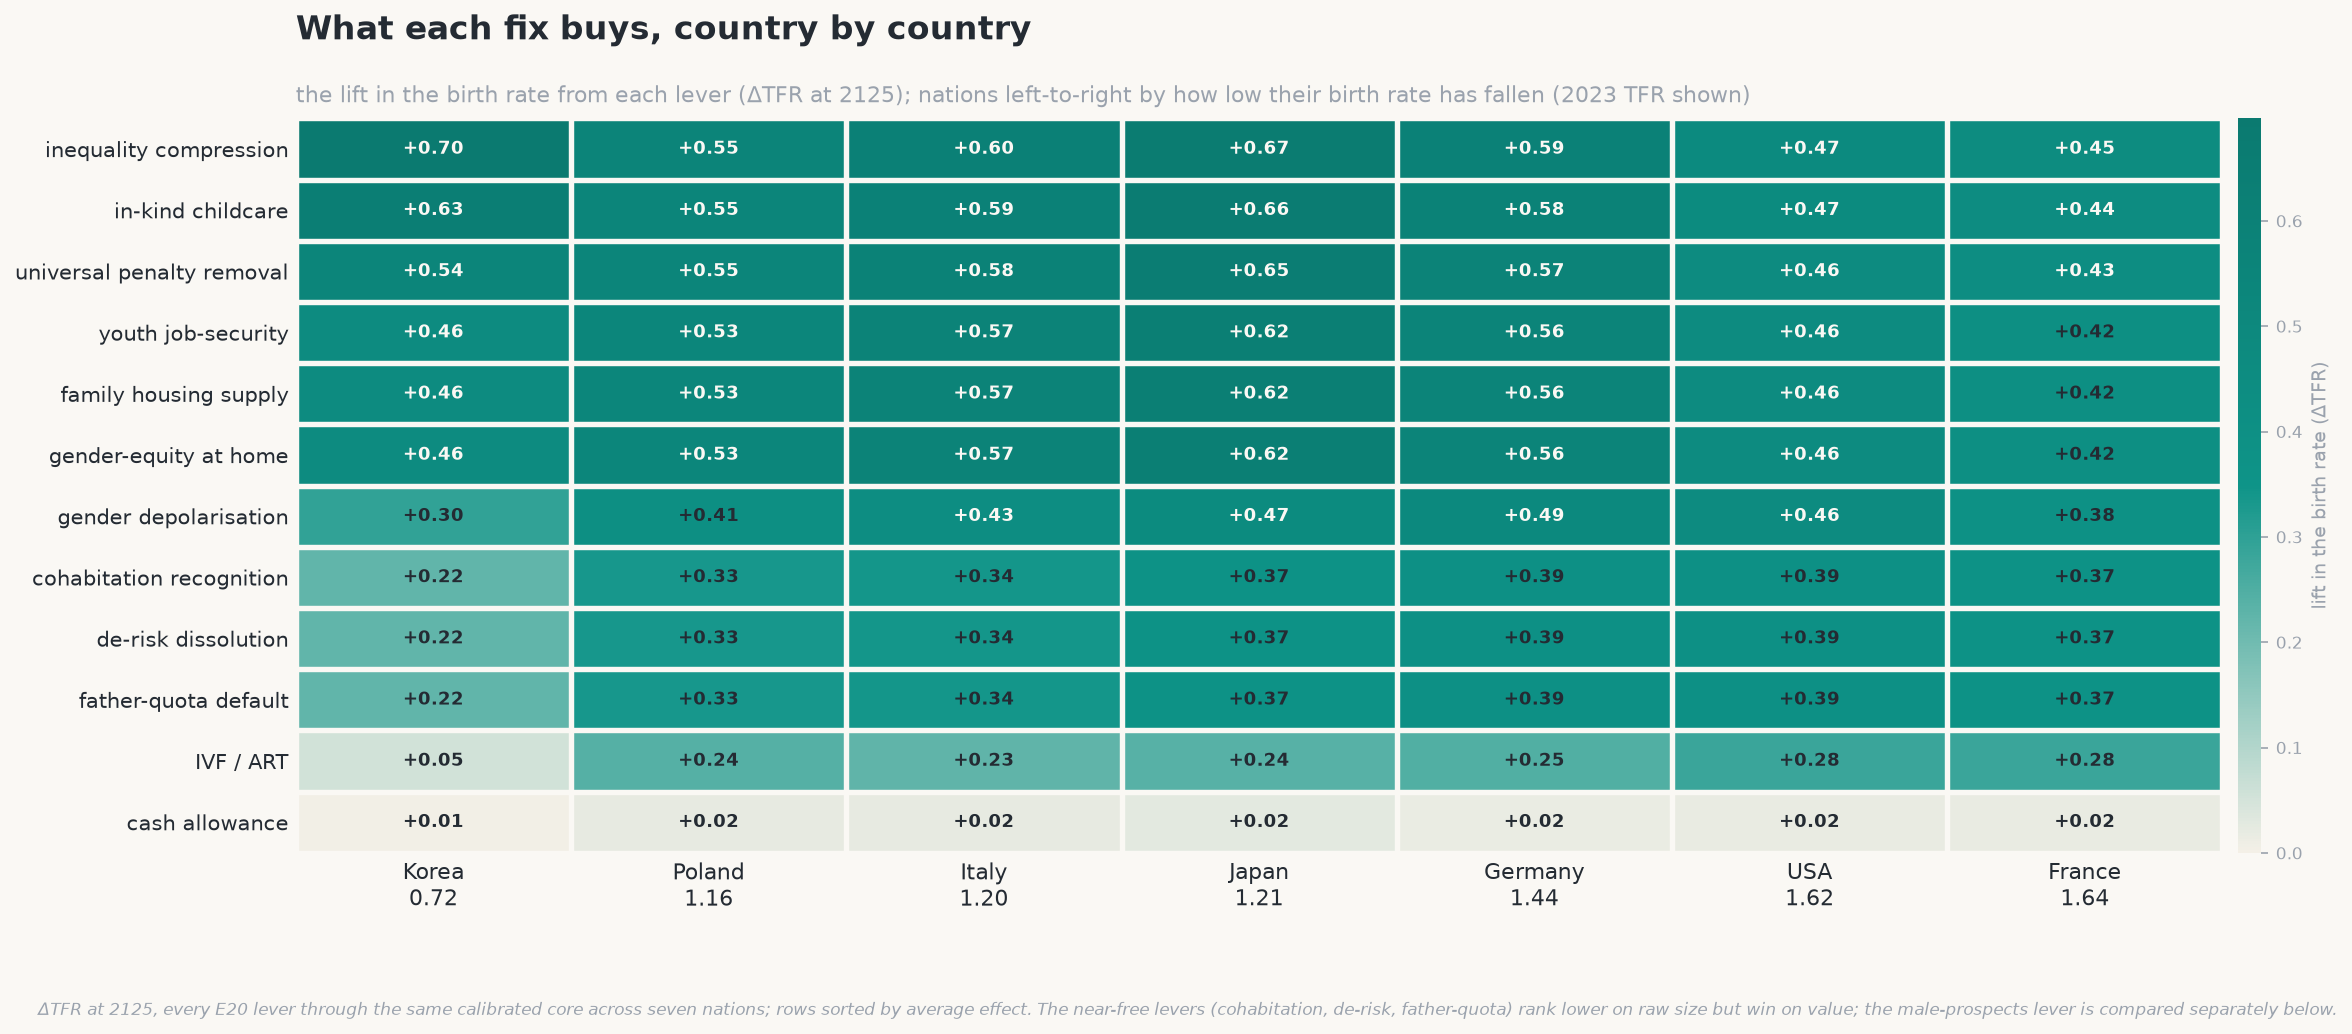

In [7]:
# ---- Every lever through the SAME calibrated core (run_cal), for every nation ----
# The old ranking used an abstract efficiency ratio on Korea alone and the retired seldon model. Here the
# E20 harbinger pool is re-run through the current calibrated distributional core (EmergentModel.run_cal)
# across all six calibrated nations, as ΔTFR (children per woman) - the relatable unit. The same grid
# feeds Figure 6 (the male lever vs the strongest fix, per nation).
from matplotlib.colors import Normalize
from sci_demographic_collapse.emergent import EmergentModel, ramp as _ramp
_m = EmergentModel(data_dir=str(PROJ/'data'/'raw'/'unwpp'))
_NAT = ['Korea','Poland','Italy','Japan','Germany','USA','France']   # by 2023 TFR, worst first
_T2023 = {'Korea':0.72,'Poland':1.16,'Italy':1.20,'Japan':1.21,'Germany':1.44,'USA':1.62,'France':1.64}
_BASE = {r:_m.run_cal(r) for r in _NAT}
def _f9(fS=0,fC=0,fPb=0,fq=0,durable=True,d=10):
    def fy(yr):
        s=_ramp(yr,d=d)*(1.0 if durable else np.exp(-max(yr-12,0)/12))
        return [fS*s,fC*s,fPb*s,0,0,0,fq*s,0,0]
    return fy
def _dt(r,fy): return _m.run_cal(r,fy)['tfr']-_BASE[r]['tfr']
# male-prospects saturating Hill drive, calibrated on Korea to the E22 ceiling (E36 nb32)
_gfq=_dt('Korea',_f9(fq=0.05))/0.05
_CEIL=_dt('Korea',_f9(fS=1.0*1.2*0.20,fC=0.4*0.5*0.20,fPb=0.45*3.0*0.20))
_grid=np.linspace(0.02,0.6,60); _dg=np.array([_dt('Korea',_f9(fq=f)) for f in _grid])
_QMAX=float(np.interp(_CEIL,_dg,_grid)); _I50=float(_gfq*_QMAX/0.03)
_Hill=lambda I:_QMAX*I/(_I50+I); I_REF=30.0
_mp=lambda: _f9(fq=_Hill(I_REF))
# E20 harbinger pool (name, channel, magnitude, fiscal, coercion, side) -> run_cal forcing
POOL=[('inequality compression','coup',0.26,0.6,0.2,0.2),('in-kind childcare','coup',0.24,0.8,0.1,0.1),
 ('universal penalty removal','coup',0.22,0.4,0.3,0.2),('youth job-security','coup',0.20,0.6,0.2,0.1),
 ('family housing supply','coup',0.20,0.5,0.1,0.1),('gender-equity at home','coup',0.20,0.3,0.2,0.2),
 ('gender depolarisation','coup',0.15,0.1,0.3,0.2),('cohabitation recognition','coup',0.12,0.1,0.1,0.05),
 ('de-risk dissolution','coup',0.12,0.3,0.1,0.05),('father-quota default','coup',0.12,0.3,0.2,0.1),
 ('cash allowance','cash',0.10,0.9,0.1,0.1),('IVF / ART','quant',0.10,0.4,0.1,0.2)]
def _hf(ch,mag):
    if ch=='coup': return _f9(fS=1.2*mag,fC=0.5*mag)
    if ch=='quant': return _f9(fPb=3.0*mag)
    return _f9(fPb=3.0*mag,durable=False)  # cash decays
LEVGRID={nm:{r:_dt(r,_hf(ch,mag)) for r in _NAT} for nm,ch,mag,fi,co,si in POOL}
MP_NAT={r:_dt(r,_mp()) for r in _NAT}
INEQ_NAT=LEVGRID['inequality compression']
rprint('[green]lever x nation grid computed via run_cal[/green]  '
       f"Korea inequality {INEQ_NAT['Korea']:+.2f}  male-prospects {MP_NAT['Korea']:+.2f}")

# Figure A: composite heatmap - what each fix buys, country by country
levers=sorted(LEVGRID,key=lambda l:np.mean(list(LEVGRID[l].values())),reverse=True)
Mtx=np.array([[LEVGRID[l][n] for n in _NAT] for l in levers])
HM=LinearSegmentedColormap.from_list('lift',['#f4f0e7',HOPE,HOPE_D])
fig=plt.figure(figsize=(15.2,7.2))
ax=fig.add_axes([0.12,0.13,0.845,0.68])   # explicit wide heatmap - span the whole frame
im=ax.imshow(Mtx,cmap=HM,aspect='auto',vmin=0,vmax=float(Mtx.max()))
ax.set_xticks(range(len(_NAT))); ax.set_xticklabels([f"{n}\n{_T2023[n]:.2f}" for n in _NAT],fontsize=10.5,color=INK)
ax.set_yticks(range(len(levers))); ax.set_yticklabels(levers,fontsize=10,color=INK)
for i in range(len(levers)):
    for j in range(len(_NAT)):
        v=Mtx[i,j]; ax.text(j,i,f'+{v:.2f}',ha='center',va='center',fontsize=8.6,
                            color=(PAPER if v>0.42 else INK),fontweight='bold')
ax.set_xticks(np.arange(-.5,len(_NAT),1),minor=True); ax.set_yticks(np.arange(-.5,len(levers),1),minor=True)
ax.grid(which='minor',color=PAPER,lw=2.6); ax.tick_params(which='both',length=0)
for sp in ax.spines.values(): sp.set_visible(False)
cax=fig.add_axes([0.972,0.13,0.010,0.68])   # colorbar hugs the right edge, no dead gap
cb=fig.colorbar(im,cax=cax); cb.set_label('lift in the birth rate (ΔTFR)',fontsize=9,color=MUTED)
cb.ax.tick_params(labelsize=8,color=MUTED); cb.outline.set_visible(False)
titled(ax,'What each fix buys, country by country',
       'the lift in the birth rate from each lever (ΔTFR at 2125); nations left-to-right by how low their birth rate has fallen (2023 TFR shown)')
caption(fig,'ΔTFR at 2125, every E20 lever through the same calibrated core across seven nations; rows sorted by average effect. The near-free levers (cohabitation, de-risk, father-quota) rank lower on raw size but win on value; the male-prospects lever is compared separately below.')
plt.savefig(FIGS/'story_cheapest_fixes.png'); plt.show()

## Figure 5 - Seldon's manifold: the fate map, seen from above

The whole story on one plane, viewed from directly overhead. Birth rate runs left to right, economic and social
security bottom to top, and colour is fate: bright green where a country has crossed into survival, glowing red
deep in the extinction basin, amber on the knife-edge between. The ridge - the watershed a civilisation must
climb and keep climbing to survive - is the model's own separatrix, the crest of its double-well fate potential;
it is not a line drawn to a number, and the fact that it lands at ~1.5 children, exactly where Lutz et al. placed
the danger line independently from real data, is the validation, not the source. It is not straight; it bows with
security. Countries are stars,
coloured by which side of it they have fallen on. The grim part is plain on the map: most of the plane is red,
and the arrow of an untended trajectory points down into it.

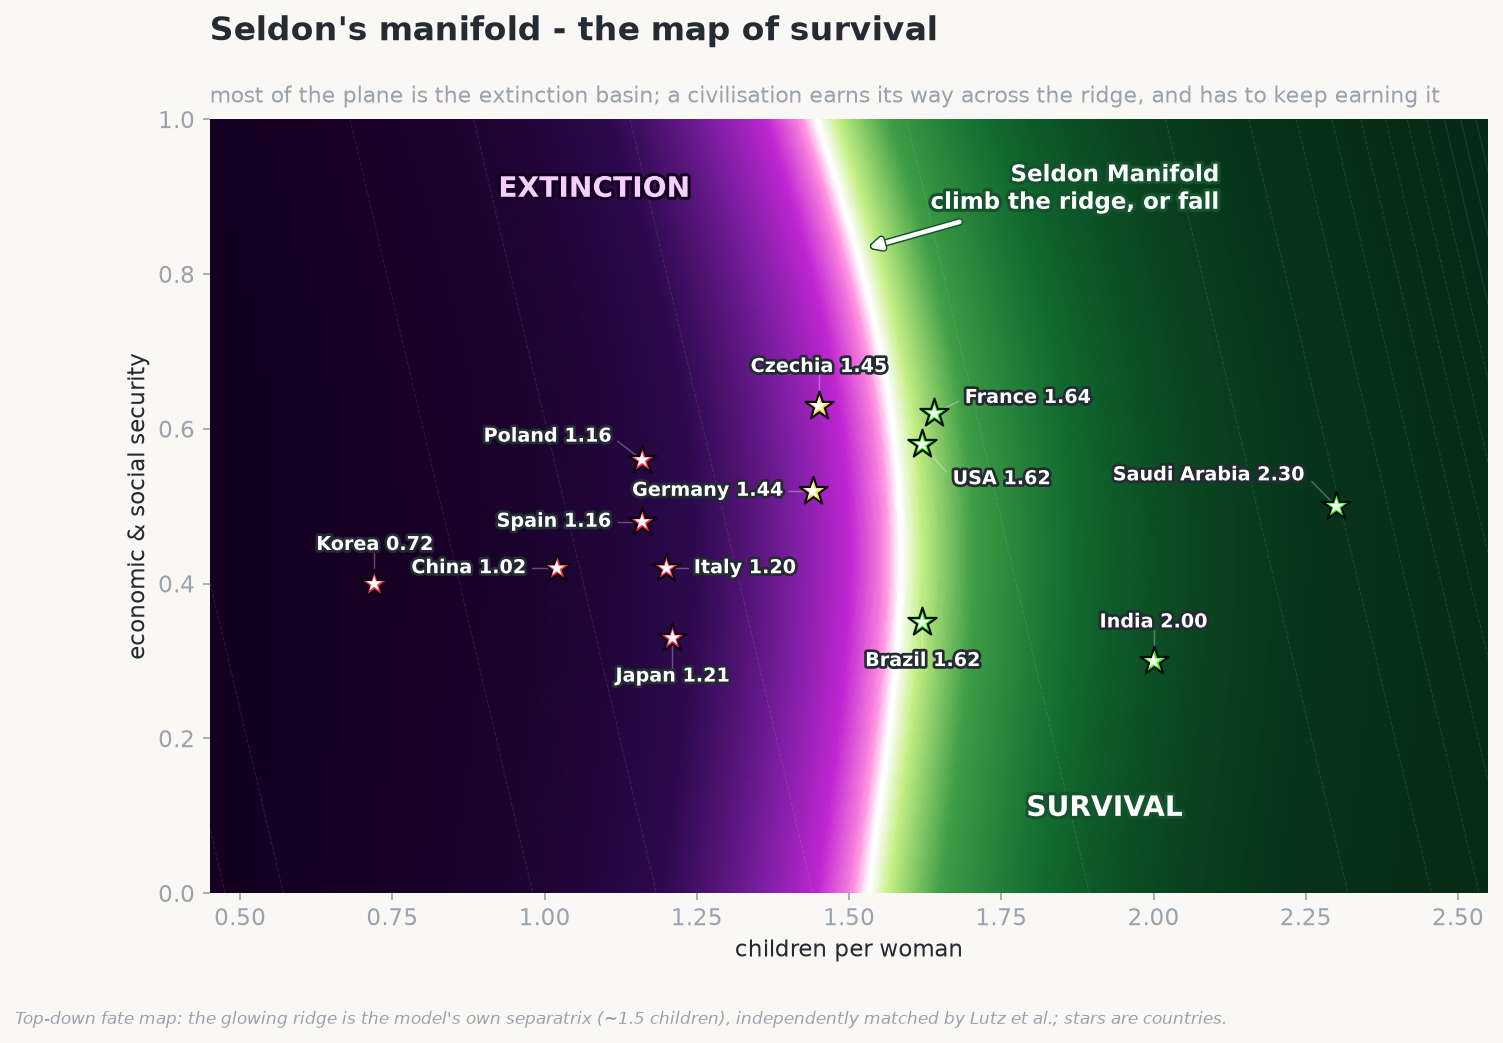

In [8]:
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap as LSC
b = 1.50   # the separatrix = the middle unstable root of the model's own double-well fate potential V' (below).
           # the stylized nine-state model measured this separatrix at 1.47-1.66 (E2-H8); Lutz et al.'s 1.5 is the
           # independent real-world validation, not the source - the ridge emerges from the simulation's bistability.
def ridge_x(y):                                  # the watershed - curved, bows with security, stays near the separatrix
    return b - 0.12*(y-0.5) + 0.085*np.sin(3.4*(y-0.10))
def _V(x): return x**4/4 - (0.60+b+2.0)*x**3/3 + (0.60*b+0.60*2.0+b*2.0)*x**2/2 - 0.60*b*2.0*x
gx = np.linspace(0.45, 2.55, 480); gy = np.linspace(0.0, 1.0, 340)
XX, YY = np.meshgrid(gx, gy)
F = np.tanh(2.4*(XX - ridge_x(YY)))              # fate field in [-1,1]: <0 extinction, >0 survival, 0 at the glowing ridge
# hot-white ridge, descending into a dark-purple extinction basin on one side and a green survival basin on the other
# white pinned to 0.5 so the colormap crest lines up exactly with F=0, i.e. the drawn ridge line at x=ridge_x(y)
FATE = LSC.from_list("fate", [
    (0.00, "#140021"), (0.16, "#2d0a4e"), (0.30, "#7c1fa2"), (0.40, "#c026d3"), (0.47, "#ff8be0"),
    (0.50, "#ffffff"),
    (0.54, "#c6f086"), (0.64, "#3f9e46"), (0.80, "#116b30"), (1.00, "#052a15")])   # darker green survival basin
fig, ax = plt.subplots(figsize=(11.0, 6.7))
ax.set_facecolor("#140021")
ax.pcolormesh(XX, YY, F, cmap=FATE, shading="gouraud", vmin=-1, vmax=1, zorder=0)
ax.contour(XX, YY, _V(XX + 0.30*(YY-0.5)), levels=16, colors="white", alpha=0.10, linewidths=0.5, zorder=1)  # faint slope lines
ry = np.linspace(0, 1, 240); rx = ridge_x(ry)     # the ridge - a glowing hot-white neon watershed with a bloom
for lw, al in [(18, 0.05), (11, 0.09), (6, 0.20), (3, 0.55), (1.4, 1.0)]:  # bloom -> incandescent core
    ax.plot(rx, ry, color="white", lw=lw, alpha=al, zorder=3, solid_capstyle="round")
ax.annotate("Seldon Manifold\nclimb the ridge, or fall", xy=(ridge_x(0.83), 0.83), xytext=(2.11, 0.91),
            fontsize=11, fontweight="bold", color="white", ha="right", va="center", zorder=9,
            path_effects=[pe.withStroke(linewidth=3.0, foreground="#14532d")],
            arrowprops=dict(arrowstyle="-|>", color="white", lw=2.2, shrinkA=2, shrinkB=6,
                            connectionstyle="arc3,rad=0.0",
                            path_effects=[pe.withStroke(linewidth=3.6, foreground="#14532d")]))
ax.text(1.08, 0.90, "EXTINCTION", color="#f5d0ff", fontsize=13.5, fontweight="bold", ha="center", zorder=5,
        path_effects=[pe.withStroke(linewidth=3, foreground="#140021")])   # mirror of SURVIVAL (1.92,0.10) about the plot centre
ax.text(1.92, 0.10, "SURVIVAL", color="white", fontsize=13.5, fontweight="bold", ha="center", zorder=5,
        path_effects=[pe.withStroke(linewidth=3, foreground="#14532d")])
CT = {"USA": 1.62, "France": 1.64, "Germany": 1.44, "Poland": 1.16, "Italy": 1.20, "Japan": 1.21, "Korea": 0.72,
      "Saudi Arabia": 2.30, "China": 1.02, "India": 2.00, "Czechia": 1.45, "Spain": 1.16, "Brazil": 1.62}
SEC = {"USA": .58, "France": .62, "Germany": .52, "Italy": .45, "Japan": .45, "Korea": .40, "Poland": .46,
       "Saudi Arabia": .50, "China": .42, "India": .30, "Czechia": .55, "Spain": .48, "Brazil": .35}  # security y-position (visual, story map only)
def star_col(t): return "#39ff14" if t >= 1.55 else ("#fde047" if t >= 1.38 else "#ff2d55")  # green safe / amber edge / red dying
pjit = {"Poland": 0.10, "Spain": 0.0, "Italy": -0.03, "Japan": -0.12, "Czechia": 0.08}   # fan the crowded 1.16/1.20 and 1.44 clusters vertically
# each label pushed onto its clear side so it hugs its star but never lands on a neighbour or the ridge
loff = {"Korea": (0.0, 0.05, "center"), "China": (-0.05, 0.0, "right"),
        "Poland": (-0.05, 0.03, "right"), "Spain": (-0.05, 0.0, "right"),
        "Italy": (0.045, 0.0, "left"), "Japan": (0.0, -0.05, "center"),
        "Germany": (-0.05, 0.0, "right"), "Czechia": (0.0, 0.05, "center"),
        "USA": (0.05, -0.045, "left"), "Brazil": (0.0, -0.05, "center"),
        "France": (0.05, 0.02, "left"), "India": (0.0, 0.05, "center"),
        "Saudi Arabia": (-0.05, 0.04, "right")}
for nm, t in CT.items():
    s = SEC[nm] + pjit.get(nm, 0.0); col = star_col(t)
    # no external bloom: the glow is clipped to the star outline, so nothing bleeds past it
    ax.scatter([t], [s], s=205, marker="*", color="#0a0a12", zorder=6.4)                       # dark backing -> thin contrast ring / crisp outline
    ax.scatter([t], [s], s=165, marker="*", color=col, edgecolor="#0a0a12", linewidth=0.6, zorder=6.6)  # bright core with a thin dark rim so greens pop
    ax.scatter([t], [s], s=60, marker="*", color="white", alpha=0.98, edgecolor="none", zorder=7)       # white heart
    dx, dy, ha = loff.get(nm, (0.0, 0.055, "center"))
    ax.plot([t, t + 0.80*dx], [s, s + 0.80*dy], color="white", lw=0.7, alpha=0.30, zorder=5.6, solid_capstyle="round")  # pale leader star -> label, kills any ambiguity
    ax.annotate(f"{nm} {t:.2f}", (t + dx, s + dy), ha=ha, va="center", fontsize=9.2, color="white", fontweight="bold",
                zorder=8, path_effects=[pe.withStroke(linewidth=2.6, foreground=INK)])
ax.set_xlim(0.45, 2.55); ax.set_ylim(0, 1)
ax.set_xlabel("children per woman"); ax.set_ylabel("economic & social security")
for sp in ax.spines.values(): sp.set_visible(False)
titled(ax, "Seldon's manifold - the map of survival",
       "most of the plane is the extinction basin; a civilisation earns its way across the ridge, and has to keep earning it")
caption(fig, "Top-down fate map: the glowing ridge is the model's own separatrix (~1.5 children), independently matched by Lutz et al.; stars are countries.")
plt.savefig(FIGS / "story_manifold.png", dpi=210, bbox_inches="tight", pad_inches=0.15); plt.show()

## Figure 6 - The male lever against the strongest fix

Per nation, the male-income lever vs narrowing inequality (the strongest broad fix in the pool), both run through the same calibrated core. Inequality compression leads in every country - the male lever's importance is the margin it reaches (young men), not its magnitude.

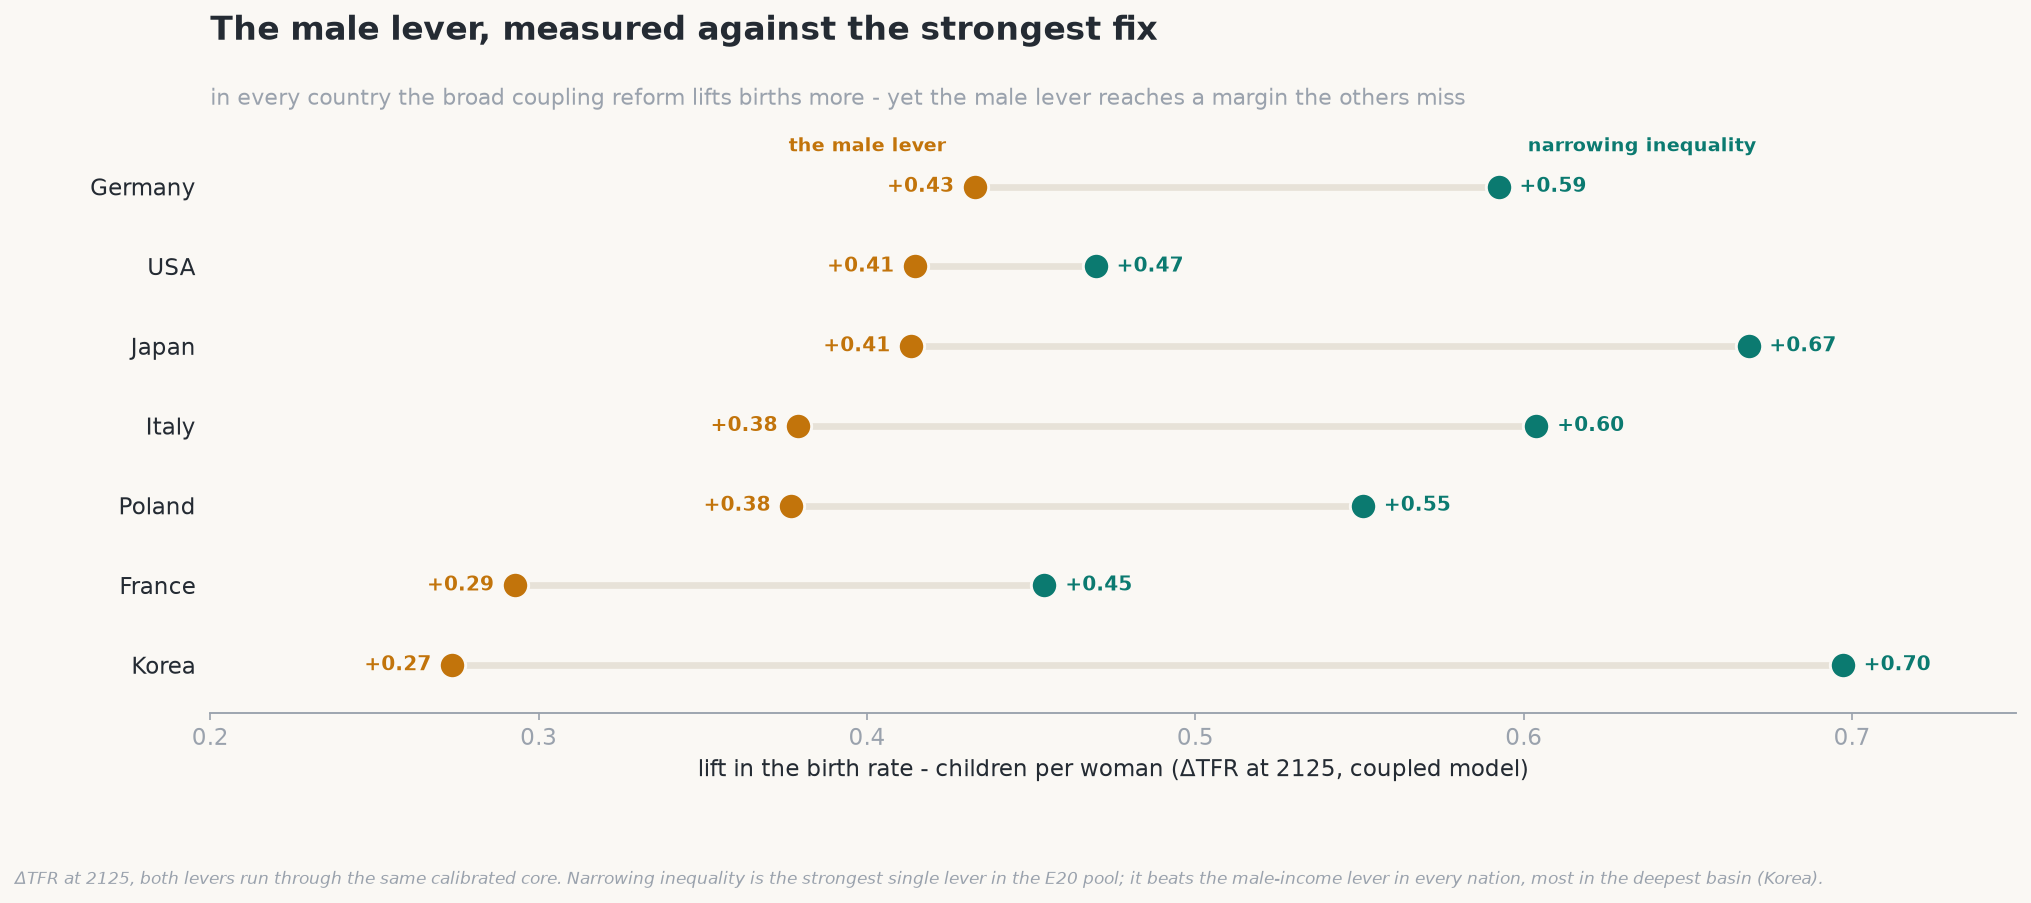

male-lever-vs-strongest-fix figure written

In [9]:
# ---- Figure 6: the male lever against the strongest fix, nation by nation (dumbbell) ----
# Uses MP_NAT and INEQ_NAT from the grid above. Honest head-to-head: narrowing inequality (the strongest
# broad coupling reform in the E20 pool) beats restoring young men's income in every nation - most in the
# deepest basin. Direct labels on the top row, no legend box (avoids the earlier overlap).
order=sorted(_NAT,key=lambda r:MP_NAT[r]); topi=len(order)-1
fig=plt.figure(figsize=(14.0,6.0))
ax=fig.add_axes([0.10,0.17,0.86,0.66])   # wide dumbbell - fill the frame (caption fits inside)
for i,r in enumerate(order):
    a,b=MP_NAT[r],INEQ_NAT[r]
    ax.plot([a,b],[i,i],color=GRID,lw=3.2,zorder=1,solid_capstyle='round')
    ax.scatter([a],[i],s=160,color=GOLD,zorder=3,edgecolor=PAPER,linewidth=1.4)
    ax.scatter([b],[i],s=160,color=HOPE_D,zorder=3,edgecolor=PAPER,linewidth=1.4)
    ax.annotate(f'+{a:.2f}',(a,i),xytext=(-10,0),textcoords='offset points',va='center',ha='right',fontsize=9.5,color=GOLD,fontweight='bold')
    ax.annotate(f'+{b:.2f}',(b,i),xytext=(10,0),textcoords='offset points',va='center',ha='left',fontsize=9.5,color=HOPE_D,fontweight='bold')
# direct labels on the top row, tucked into empty space (no legend box)
ax.annotate('the male lever',(MP_NAT[order[topi]],topi),xytext=(-14,17),textcoords='offset points',ha='right',fontsize=9,color=GOLD,fontweight='bold')
ax.annotate('narrowing inequality',(INEQ_NAT[order[topi]],topi),xytext=(14,17),textcoords='offset points',ha='left',fontsize=9,color=HOPE_D,fontweight='bold')
ax.set_yticks(range(len(order))); ax.set_yticklabels(order,fontsize=11,color=INK)
ax.set_xlim(0.20,0.75); ax.set_ylim(-0.6,len(order)-0.15)   # zoom to the data band (both levers labelled)
ax.set_xlabel('lift in the birth rate - children per woman (ΔTFR at 2125, coupled model)')
ax.spines['left'].set_visible(False); ax.tick_params(left=False)
titled(ax,'The male lever, measured against the strongest fix',
       'in every country the broad coupling reform lifts births more - yet the male lever reaches a margin the others miss')
caption(fig,'ΔTFR at 2125, both levers run through the same calibrated core. Narrowing inequality is the strongest single lever in the E20 pool; it beats the male-income lever in every nation, most in the deepest basin (Korea).')
plt.savefig(FIGS/'story_male_prospects.png'); plt.show()
rprint('[green]male-lever-vs-strongest-fix figure written[/green]')

## The images

All six render to `reports/figures/story_*.png` at 210 dpi on warm paper, ready to embed in the README. They
carry the narrative's beats in one restrained visual language: teal is recovery, rose is decline, and the
ridge is the thin line between them.